In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import warnings

# 忽略警告信息
warnings.filterwarnings('ignore')

# 设置随机种子以保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 检查是否有可用的GPU，否则使用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from torchvision.datasets import MNIST
from torchvision import transforms

def load_mnist_numpy(root="data"):
    """加载MNIST数据集并转换为Numpy格式"""
    tfm = transforms.ToTensor()  # 定义转换：[0,1]，shape: [1,28,28]
    
    # 下载并加载训练集和测试集
    train_ds = MNIST(root=root, train=True, download=True, transform=tfm)
    test_ds  = MNIST(root=root, train=False, download=True, transform=tfm)

    # 提取数据和标签并转换为numpy数组
    train_data  = train_ds.data.numpy()        
    train_label = train_ds.targets.numpy().astype(np.int64)
    test_data   = test_ds.data.numpy()
    test_label  = test_ds.targets.numpy().astype(np.int64)
    return train_data, train_label, test_data, test_label

# 加载数据
train_data, train_label, test_data, test_label = load_mnist_numpy(root="data")
print("train_data:", train_data.shape, train_data.dtype)
print("train_label:", train_label.shape, train_label.dtype)
print("test_data:", test_data.shape, test_data.dtype)
print("test_label:", test_label.shape, test_label.dtype)

class MNISTDataset(Dataset):
    """自定义Dataset类，用于PyTorch数据加载"""
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels.astype(np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 数据预处理：归一化和展平
        x = self.data[idx].astype(np.float32) / 255.0     # 归一化 (28,28) -> [0,1]
        x = x.reshape(-1)                                 # 展平 (784,)
        y = self.labels[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

# 实例化Dataset对象
train_dataset = MNISTDataset(train_data, train_label)
test_dataset  = MNISTDataset(test_data, test_label)

train_data: (60000, 28, 28) uint8
train_label: (60000,) int64
test_data: (10000, 28, 28) uint8
test_label: (10000,) int64


In [ ]:
class MLP(nn.Module):
    """多层感知机"""
    def __init__(
            self, 
            input_size=784, 
            hidden_sizes=[128], 
            output_size=10, 
            activation='relu', 
            ):
        super(MLP, self).__init__()
        # 构建网络层列表
        layers = []
        prev_size = input_size
        
        # 循环构建隐藏层
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size)) # 全连接层
            # 根据配置选择激活函数
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU())
            else:
                layers.append(nn.ReLU()) # 默认使用ReLU
            prev_size = hidden_size
            
        # 添加输出层
        layers.append(nn.Linear(prev_size, output_size))
        
        # 将列表解包并封装为Sequential容器
        self.network = nn.Sequential(*layers)
        
        # 保存网络参数
        self.hidden_sizes = hidden_sizes
        self.activation = activation
        
    def forward(self, x):
        """前向传播"""
        return self.network(x)
    
def create_model(cfg):
    """根据配置字典创建模型实例"""
    return MLP(
        input_size=cfg.get("input_size", 784),
        hidden_sizes=cfg.get("hidden_sizes", [128]),
        output_size=cfg.get("output_size", 10),
        activation=cfg.get("activation", "relu"),
    )

In [ ]:
def train_model(model, config, num_epochs=10):
    """训练模型"""
    # 配置信息
    name = config['name']
    batch_size = config.get('batch_size', 128)
    learning_rate = config.get('learning_rate', 1e-3)
    
    # 创建日志文件夹和文件
    log_dir = "output"
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, f"{name}.log")
    
    # 初始化日志文件头
    with open(log_file, "w") as log:
        log.write("Epoch,Train Loss,Train Accuracy,Test Loss,Test Accuracy\n")
    
    # 数据加载器
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 定义损失函数(交叉熵)和优化器(Adam)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # 记录训练过程指标
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    
    # 训练循环
    for epoch in tqdm(range(num_epochs), desc=f"Training {config['name']:<12}"):
        # --- 训练阶段 ---
        model.train()
        epoch_train_loss = 0.0
        train_preds = []
        train_labels = []
        
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()           # 清空梯度
            output = model(data)            # 前向传播
            loss = criterion(output, target)# 计算损失
            loss.backward()                 # 反向传播
            optimizer.step()                # 更新参数
            
            epoch_train_loss += loss.item()
            
            # 收集预测结果用于计算准确率
            _, predicted = torch.max(output.data, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(target.cpu().numpy())
        
        # 计算本轮训练损失和准确率
        train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(train_loss)
        train_acc = accuracy_score(train_labels, train_preds)
        train_accuracies.append(train_acc)
        
        # --- 测试阶段 ---
        model.eval()
        epoch_test_loss = 0.0
        test_preds = []
        test_labels = []
        
        with torch.no_grad(): # 禁用梯度计算
            for data, target in test_loader:
                output = model(data)
                loss = criterion(output, target)
                epoch_test_loss += loss.item()
                
                _, predicted = torch.max(output.data, 1)
                test_preds.extend(predicted.cpu().numpy())
                test_labels.extend(target.cpu().numpy())
        
        # 计算本轮测试损失和准确率
        test_loss = epoch_test_loss / len(test_loader)
        test_losses.append(test_loss)
        test_acc = accuracy_score(test_labels, test_preds)
        test_accuracies.append(test_acc)
        
        # 写入日志文件
        with open(log_file, "a") as log:
            log.write(f"{epoch+1},{train_loss:.4f},{train_acc:.4f},{test_loss:.4f},{test_acc:.4f}\n")
    
    # 最终评估结果记录
    final_train_accuracy = train_accuracies[-1]
    final_test_accuracy = test_accuracies[-1]
    with open(log_file, "a") as log:
        log.write("\n")
        log.write(f"Final Train Accuracy: {final_train_accuracy:.4f}\n")
        log.write(f"Final Test Accuracy: {final_test_accuracy:.4f}\n")
    
    # 返回训练结果字典
    return {
        'model': model,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies,
        'final_train_accuracy': final_train_accuracy,
        'final_test_accuracy': final_test_accuracy,
        'config': config
    }

In [5]:
def plot_results(results):
    """绘制训练结果"""
    plt.figure(figsize=(20, 5))

    # 训练损失曲线
    ax1 = plt.subplot(141)
    for model_key, result in results.items():
        ax1.plot(result['train_losses'], label=f"{result['config']['name']}")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 训练准确率曲线
    ax2 = plt.subplot(142)
    for model_key, result in results.items():
        ax2.plot(result['train_accuracies'], label=f"{result['config']['name']}")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # 测试损失曲线
    ax3 = plt.subplot(143)
    for model_key, result in results.items():
        ax3.plot(result['test_losses'], linestyle='--', label=f"{result['config']['name']}")
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.set_title('Test Loss')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.5)

    # 测试准确率曲线
    ax4 = plt.subplot(144)
    for model_key, result in results.items():
        ax4.plot(result['test_accuracies'], linestyle='--', label=f"{result['config']['name']}")
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Test Accuracy')
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

Training default     : 100%|██████████| 10/10 [00:51<00:00,  5.19s/it]


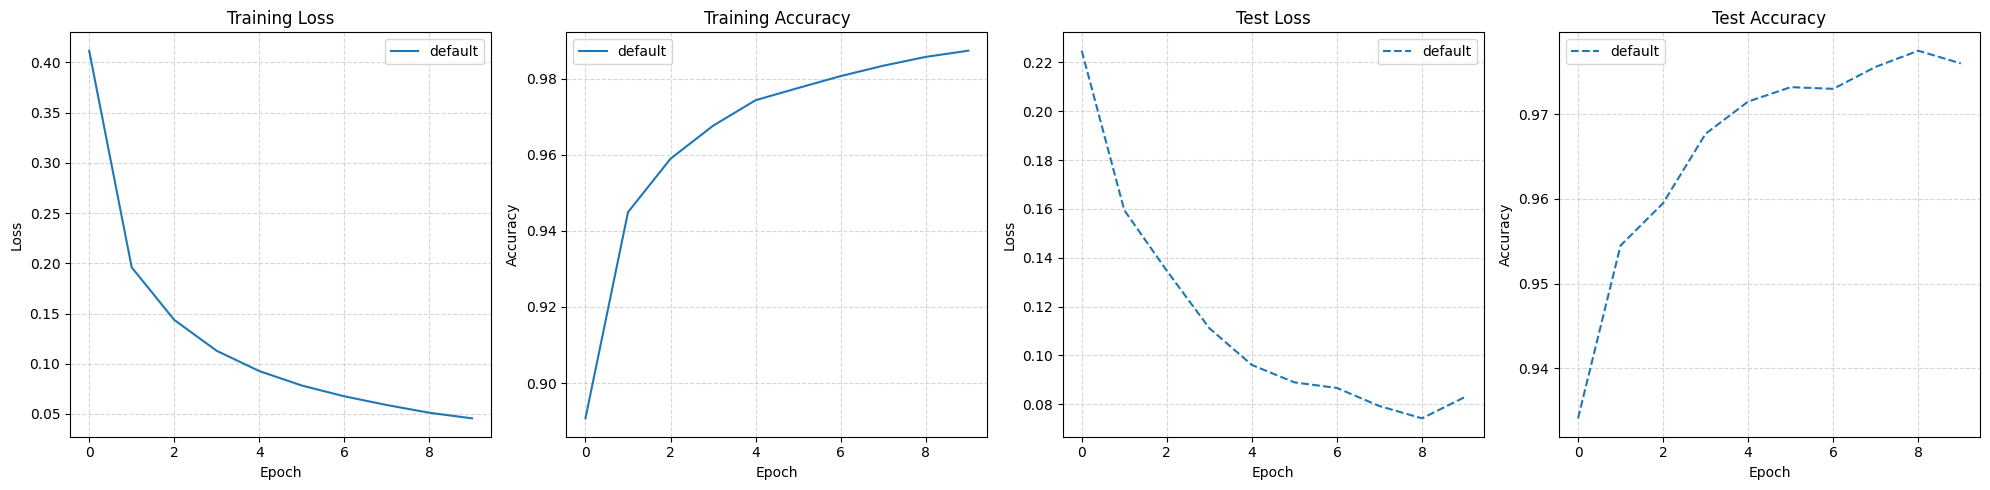

In [6]:
# 默认配置
default_config = {
    'name': 'default',
    'hidden_sizes': [128],
    'activation': 'relu',
    'batch_size': 128,
    'learning_rate': 1e-3
}

results = {}
model = create_model(default_config)
results['default'] = train_model(model, default_config, num_epochs=10)
plot_results(results)

Training AF_leakyrelu: 100%|██████████| 10/10 [00:47<00:00,  4.76s/it]


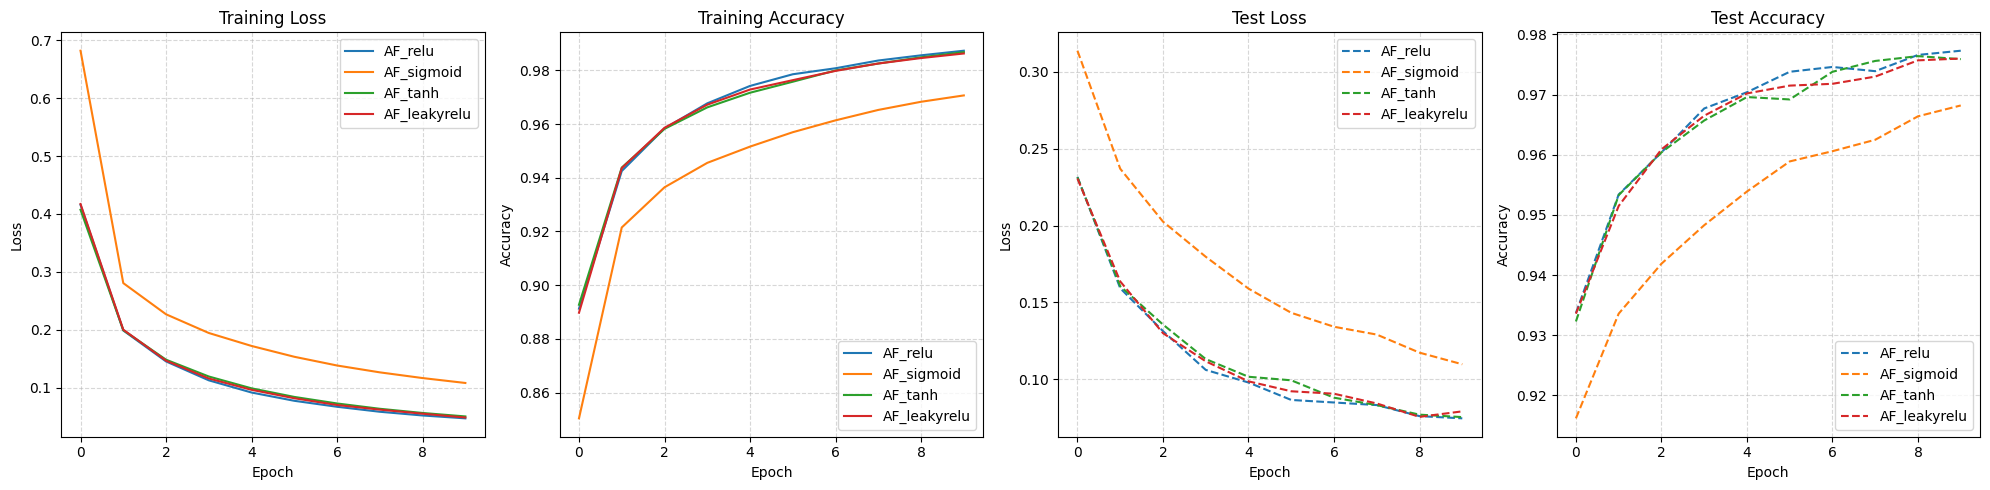

In [7]:
# 不同激活函数
configs = {
    'cfg1': {
        'name': 'AF_relu',
        'activation': 'relu'
    },
    'cfg2': {
        'name': 'AF_sigmoid',
        'activation': 'sigmoid'
    },
    'cfg3': {
        'name': 'AF_tanh',
        'activation': 'tanh'
    },
    'cfg4': {
        'name': 'AF_leakyrelu',
        'activation': 'leaky_relu'
    }
}

results = {}
for model_key, config in configs.items(): 
    # 创建模型
    model = create_model(config)
    # 训练模型
    results[model_key] = train_model(model, config, num_epochs=10)

plot_results(results)

Training HS_512      : 100%|██████████| 10/10 [00:46<00:00,  4.62s/it]


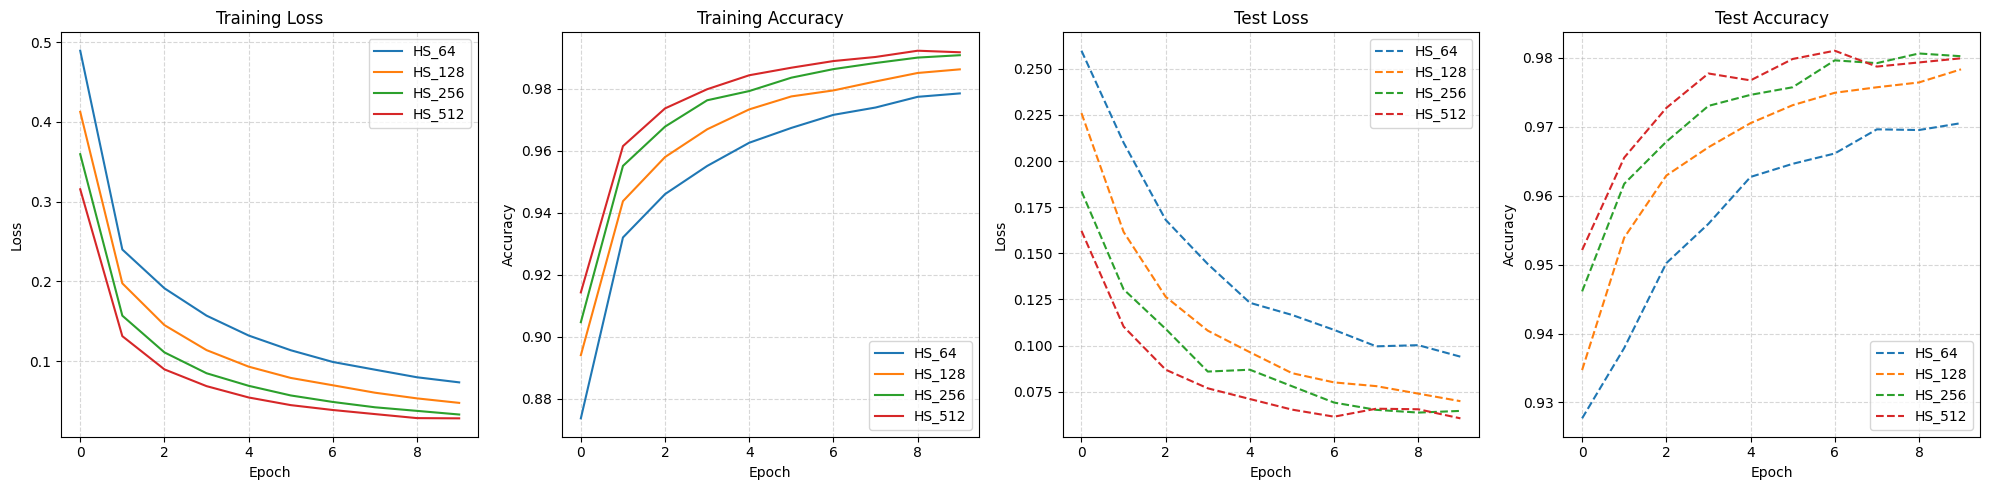

In [8]:
# 不同隐藏层大小
configs = {
    'cfg1': {
        'name': 'HS_64',
        'hidden_sizes': [64]
    },
    'cfg2': {
        'name': 'HS_128',
        'hidden_sizes': [128]
    },
    'cfg3': {
        'name': 'HS_256',
        'hidden_sizes': [256]
    },
    'cfg4': {
        'name': 'HS_512',
        'hidden_sizes': [512]
    }
}

results = {}
for model_key, config in configs.items(): 
    # 创建模型
    model = create_model(config)
    # 训练模型
    results[model_key] = train_model(model, config, num_epochs=10)

plot_results(results)

Training HL_4        : 100%|██████████| 10/10 [01:06<00:00,  6.69s/it]


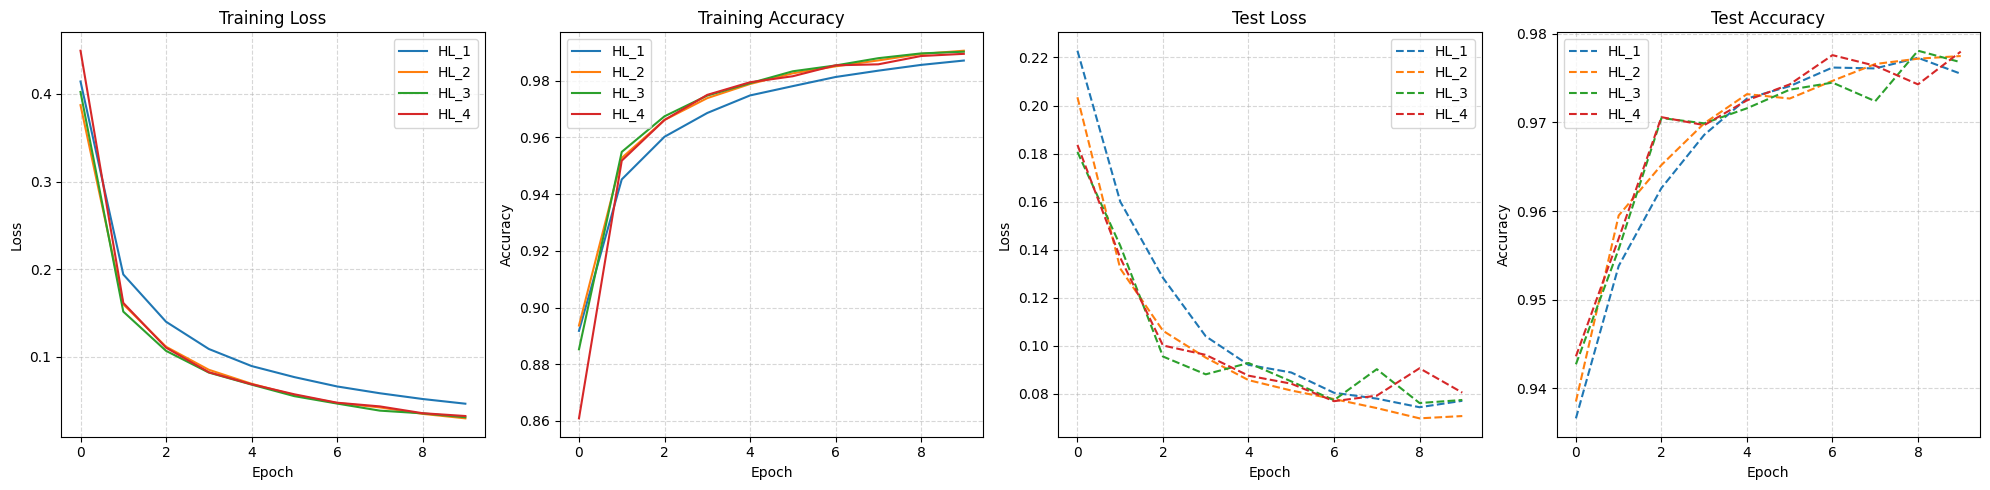

In [9]:
# 不同隐藏层层数
configs = {
    'cfg1': {
        'name': 'HL_1',
        'hidden_sizes': [128]
    },
    'cfg2': {
        'name': 'HL_2',
        'hidden_sizes': [128,128]
    },
    'cfg3': {
        'name': 'HL_3',
        'hidden_sizes': [128,128,128]
    },
    'cfg4': {
        'name': 'HL_4',
        'hidden_sizes': [128,128,128,128]
    }
}

results = {}
for model_key, config in configs.items(): 
    # 创建模型
    model = create_model(config)
    # 训练模型
    results[model_key] = train_model(model, config, num_epochs=10)

plot_results(results)

Training BS_512      : 100%|██████████| 10/10 [00:29<00:00,  2.92s/it]


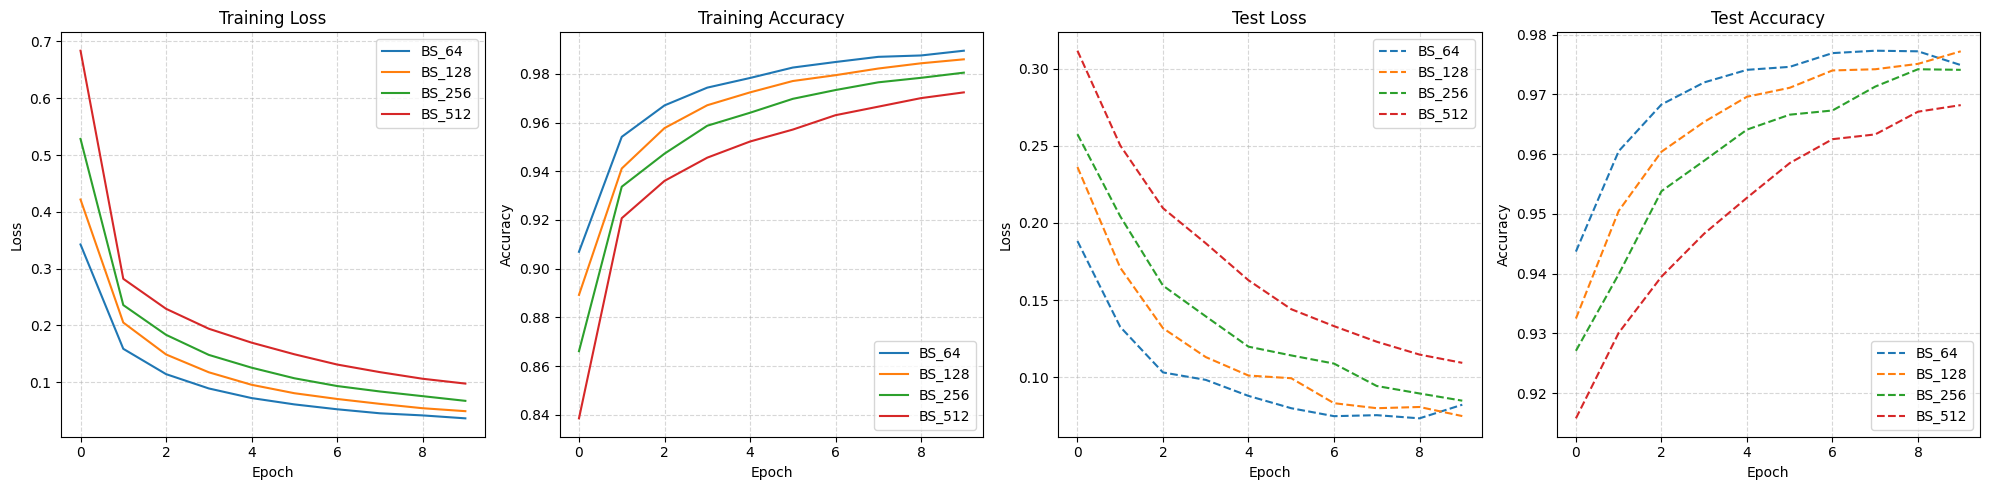

In [10]:
# 不同batch size
configs = {
    'cfg1': {
        'name': 'BS_64',
        'batch_size': 64
    },
    'cfg2': {
        'name': 'BS_128',
        'batch_size': 128
    },
    'cfg3': {
        'name': 'BS_256',
        'batch_size': 256
    },
    'cfg4': {
        'name': 'BS_512',
        'batch_size': 512
    }
}

results = {}
for model_key, config in configs.items(): 
    # 创建模型
    model = create_model(config)
    # 训练模型
    results[model_key] = train_model(model, config, num_epochs=10)

plot_results(results)

Training LR_0.0001   : 100%|██████████| 10/10 [00:42<00:00,  4.30s/it]


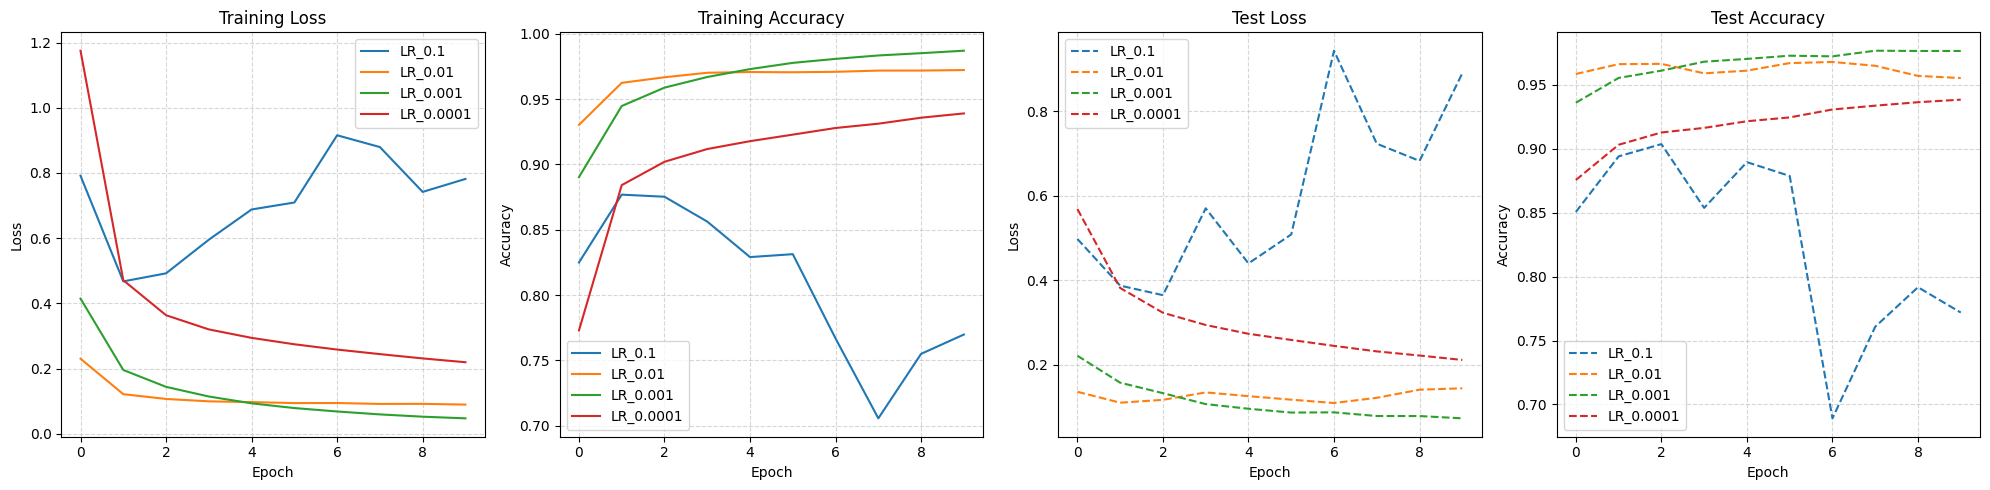

In [11]:
# 不同learning rate
configs = {
    'cfg1': {
        'name': 'LR_0.1',
        'learning_rate': 0.1
    },
    'cfg2': {
        'name': 'LR_0.01',
        'learning_rate': 0.01
    },
    'cfg3': {
        'name': 'LR_0.001',
        'learning_rate': 0.001
    },
    'cfg4': {
        'name': 'LR_0.0001',
        'learning_rate': 0.0001
    }
}

results = {}
for model_key, config in configs.items(): 
    # 创建模型
    model = create_model(config)
    # 训练模型
    results[model_key] = train_model(model, config, num_epochs=10)

plot_results(results)

In [ ]:
# 演示单次训练步骤：前向传播、反向传播、梯度计算及参数更新
with open("output/demo.txt", "w") as f:
    f.write("="*20 + " 演示单次训练步骤 " + "="*20 + "\n")

    # 1. 准备模型和数据
    demo_config = {
        'name': 'default',
        'hidden_sizes': [128],
        'activation': 'relu',
        'batch_size': 2, # 为了演示方便，使用batch_size=2
        'learning_rate': 1e-3
    }
    model = create_model(demo_config)
    # 获取一个batch的数据
    demo_loader = DataLoader(train_dataset, batch_size=demo_config['batch_size'], shuffle=True)
    images, labels = next(iter(demo_loader))
    f.write(f"\n输入数据形状: {images.shape}\n")
    f.write(f"标签: {labels}\n")
    # 定义损失函数和优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=demo_config['learning_rate'], weight_decay=1e-4)

    # 2. 前向传播 (Forward Pass)
    f.write("\n" + "-"*10 + " 前向传播 " + "-"*10 + "\n")
    # 使用hook捕获中间层输出
    layer_inputs = {}
    layer_outputs = {}
    def hook_fn(name):
        def hook(module, input, output):
            layer_inputs[name] = input[0].detach()
            layer_outputs[name] = output.detach()
        return hook
    # 注册hook到Sequential中的每一层
    for idx, layer in enumerate(model.network):
        layer.register_forward_hook(hook_fn(f"Layer_{idx}_{layer.__class__.__name__}"))
    # 执行前向传播
    outputs = model(images)
    # 展示各层信息
    for name in layer_inputs:
        f.write(f"[{name}]\n")
        f.write(f"  输入形状: {layer_inputs[name].shape}\n")
        f.write(f"  输出形状: {layer_outputs[name].shape}\n")
        # 简单展示部分数值统计
        f.write(f"  输出均值: {layer_outputs[name].mean():.4f}, 标准差: {layer_outputs[name].std():.4f}\n")
    f.write(f"\n最终模型输出 (Logits): \n{outputs}\n")

    # 3. 计算损失 (Loss Calculation)
    f.write("\n" + "-"*10 + " 计算损失 " + "-"*10 + "\n")
    loss = criterion(outputs, labels)
    f.write(f"CrossEntropyLoss: {loss.item():.4f}\n")

    # 4. 反向传播 (Backward Pass)
    f.write("\n" + "-"*10 + " 反向传播 " + "-"*10 + "\n")
    # 检查反向传播前的梯度 (应该是None或者0)
    f.write(f"反向传播前的梯度 (第一层权重): {model.network[0].weight.grad}\n")
    loss.backward()
    f.write("反向传播后的梯度范数 (Gradient Norm):\n")
    for name, param in model.named_parameters():
        if param.grad is not None:
            f.write(f"  {name}: {param.grad.norm():.4f}\n")
        else:
            f.write(f"  {name}: None\n")

    # 5. 参数更新 (Parameter Update)
    f.write("\n" + "-"*10 + " 参数更新 " + "-"*10 + "\n")
    # 选取一个参数观察更新情况 (例如第一层权重的第一个元素)
    param_to_watch = model.network[0].weight[0, 0].item()
    f.write(f"更新前参数值 (Layer 0, weight[0,0]): {param_to_watch:.6f}\n")
    optimizer.step()
    param_updated = model.network[0].weight[0, 0].item()
    f.write(f"更新后参数值 (Layer 0, weight[0,0]): {param_updated:.6f}\n")
    f.write(f"参数变化量: {param_updated - param_to_watch:.6f}\n")

print("演示完成，结果已写入 demo.txt")

演示完成，结果已写入 demo.txt
